<a href="https://colab.research.google.com/github/dee431/What-the-Open-Model-Ecosystem-Actually-Looks-Like/blob/main/What_the_Open_Model_Ecosystem_Actually_Looks_Like.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
adarsh1077_huggingface_hub_50k_ai_models_path = kagglehub.dataset_download('adarsh1077/huggingface-hub-50k-ai-models')

print('Data source import complete.')


100%|██████████| 5.03M/5.03M [00:00<00:00, 161MB/s]

Extracting files...
Data source import complete.


# 🤗 What the Open-Model Ecosystem Actually Looks Like

A tour of **50,000 HuggingFace models** — the most-downloaded slice of a hub that holds
**2,991,692** public repositories.

Rather than a generic `df.describe()` walkthrough, this notebook chases five questions
the data can genuinely settle:

1. **How open is "open"?** — licence reality vs. licence marketing
2. **Does size drive adoption?** — parameters vs. downloads
3. **When did local inference go mainstream?** — dating the quantisation wave
4. **How much of the hub is abandoned?** — staleness as a supply-chain signal
5. **What do the big labs specialise in?** — org strategy from the author rollup

> ⚠️ **Read the caveats section first.** Three columns have quirks that will
> quietly corrupt your analysis if you don't know about them.

In [3]:
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# In Colab, we use the path returned by kagglehub
try:
    BASE = adarsh1077_huggingface_hub_50k_ai_models_path
    print('reading from:', BASE)
except NameError:
    # Fallback if the download cell wasn't run
    hits = glob.glob('/kaggle/input/**/huggingface_models.csv', recursive=True)
    if not hits:
        raise FileNotFoundError('Dataset path not found. Please ensure the first cell with kagglehub.dataset_download was executed.')
    BASE = os.path.dirname(hits[0])

models  = pd.read_csv(f'{BASE}/huggingface_models.csv', low_memory=False)
authors = pd.read_csv(f'{BASE}/huggingface_authors.csv')

for c in ['created_at', 'last_modified']:
    models[c] = pd.to_datetime(models[c], errors='coerce')

print(f'models  : {models.shape[0]:,} rows x {models.shape[1]} cols')
print(f'authors : {authors.shape[0]:,} rows x {authors.shape[1]} cols')
models.head(3)

reading from: /root/.cache/kagglehub/datasets/adarsh1077/huggingface-hub-50k-ai-models/versions/3
models  : 50,000 rows x 30 cols
authors : 9,892 rows x 17 cols


,model_id,author,model_name,downloads_30d,likes,pipeline_tag,library_name,license,param_count_b,languages,...,has_gguf,has_onnx,has_pytorch_bin,has_model_card,n_tags,tags,age_days,days_since_update,created_year,likes_per_10k_downloads
0,sentence-transformers/all-MiniLM-L6-v2,sentence-transformers,all-MiniLM-L6-v2,254892100,5207,sentence-similarity,sentence-transformers,apache-2.0,NaN,en,...,False,True,True,True,47,sentence-transformers|pytorch|tf|rust|onnx|saf...,1625,74,2022,0.204
1,google-bert/bert-base-uncased,google-bert,bert-base-uncased,115858176,2733,fill-mask,transformers,apache-2.0,NaN,en,...,False,True,True,True,20,transformers|pytorch|tf|jax|rust|coreml|onnx|s...,1625,907,2022,0.236
2,cross-encoder/ms-marco-MiniLM-L6-v2,cross-encoder,ms-marco-MiniLM-L6-v2,87976556,300,text-ranking,sentence-transformers,apache-2.0,NaN,en,...,False,True,True,True,18,sentence-transformers|pytorch|jax|onnx|safeten...,1625,4,2022,0.034


## Chart styling

A single validated palette, applied once, so every chart below reads as one system.

In [5]:
# Categorical slots in fixed order (never cycled), plus recessive chrome.
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
SURFACE, INK, SECOND = '#fcfcfb', '#0b0b0b', '#52514e'
MUTED, GRID, BASELINE = '#898781', '#e1e0d9', '#c3c2b7'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': SECOND,
    'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.dpi': 110,
})

def finish(ax, title, sub=None):
    """Title + subtitle in ink, grid behind the marks, no chartjunk."""
    ax.set_title(title, fontsize=14, fontweight='bold', color=INK,
                 loc='left', pad=16 if sub else 10)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=10,
                color=SECOND, va='bottom')
    ax.set_axisbelow(True)

## ⚠️ Caveats that will bite you

Quantified, not hand-waved — run the cell to see each one.

In [6]:
# 1. created_at is BACKFILLED. HF added the field in March 2022 and stamped
#    every pre-existing repo with the same timestamp.
sentinel = models['created_at'].value_counts().head(1)
print('Most common created_at (the backfill sentinel):')
print(f'  {sentinel.index[0]}  ->  {sentinel.iloc[0]:,} models '
      f'({sentinel.iloc[0]/len(models)*100:.1f}%)')
print('  Models older than Mar-2022 CANNOT be dated. Filter before any time series.\n')

# 2. downloads_30d is a 30-day window; likes is all-time. Different time bases.
print(f"downloads_30d : {models.downloads_30d.min():,} to "
      f"{models.downloads_30d.max():,} (trailing 30 days)")
print(f"likes         : {models.likes.min():,} to {models.likes.max():,} (all-time)")
print('  Never compute a ratio of these without noting the mismatch.\n')

# 3. param_count_b is parsed from the model NAME, not read from weights.
cov = models.param_count_b.notna().mean() * 100
print(f'param_count_b populated for {cov:.1f}% of rows (name-derived, approximate)')

Most common created_at (the backfill sentinel):
  2022-03-02 23:29:05  ->  1,601 models (3.2%)
  Models older than Mar-2022 CANNOT be dated. Filter before any time series.

downloads_30d : 343 to 254,892,100 (trailing 30 days)
likes         : 0 to 14,126 (all-time)
  Never compute a ratio of these without noting the mismatch.

param_count_b populated for 56.8% of rows (name-derived, approximate)


## 1. How open is "open"?

Everyone calls these models open. The licence column disagrees more often than you'd expect.

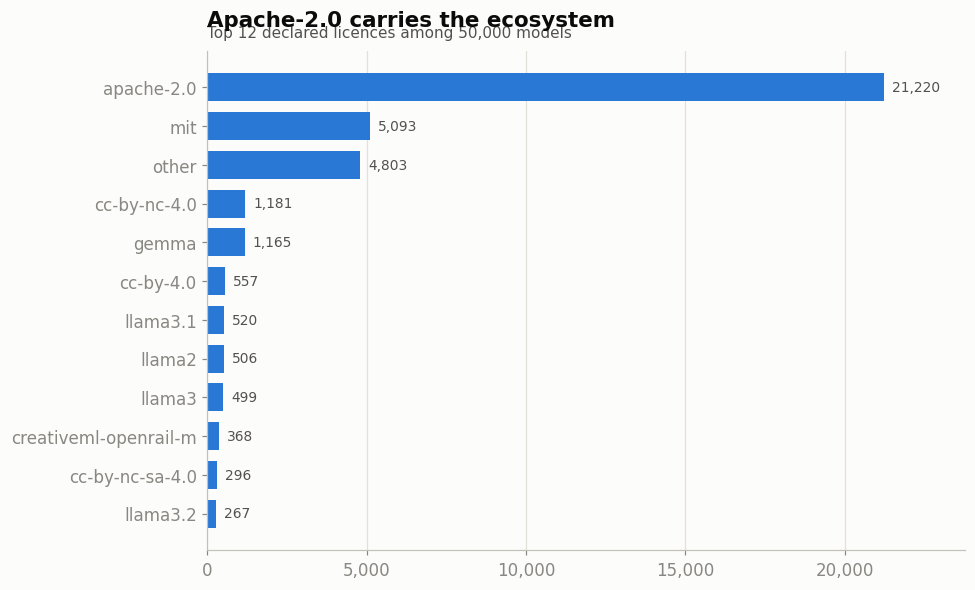

In [7]:
lic = models['license'].value_counts().head(12).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(lic.index, lic.values, color=BLUE, height=0.72)
ax.xaxis.grid(True); ax.yaxis.grid(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Direct-label each bar rather than making the reader trace back to the axis.
for y, v in enumerate(lic.values):
    ax.text(v + max(lic.values)*0.012, y, f'{v:,}', va='center',
            fontsize=9, color=SECOND)

ax.set_xlim(0, max(lic.values) * 1.12)
finish(ax, 'Apache-2.0 carries the ecosystem',
       'Top 12 declared licences among 50,000 models')
plt.tight_layout(); plt.show()

In [8]:
# Group licences into genuinely-permissive vs. restricted-or-unknown.
PERMISSIVE = {'apache-2.0','mit','bsd','bsd-3-clause','bsd-2-clause',
              'cc-by-4.0','cc0-1.0','openrail','unlicense','isc'}

def bucket(x):
    if pd.isna(x):            return 'Undeclared'
    if x in PERMISSIVE:       return 'Permissive'
    if 'nc' in str(x):        return 'Non-commercial'
    return 'Custom / restricted'

models['license_bucket'] = models['license'].apply(bucket)
share = models['license_bucket'].value_counts()
pct = (share / len(models) * 100).round(1)

for k in share.index:
    print(f'{k:22} {share[k]:>7,}  {pct[k]:>5}%')
print(f'\nTruly permissive: {pct.get("Permissive", 0)}% '
      f'-- the rest carries some restriction or no licence at all.')

Permissive              27,150   54.3%
Undeclared              11,954   23.9%
Custom / restricted      9,268   18.5%
Non-commercial           1,628    3.3%

Truly permissive: 54.3% -- the rest carries some restriction or no licence at all.


## 2. Does bigger mean more used?

The industry narrative says scale wins. The download data says something blunter.

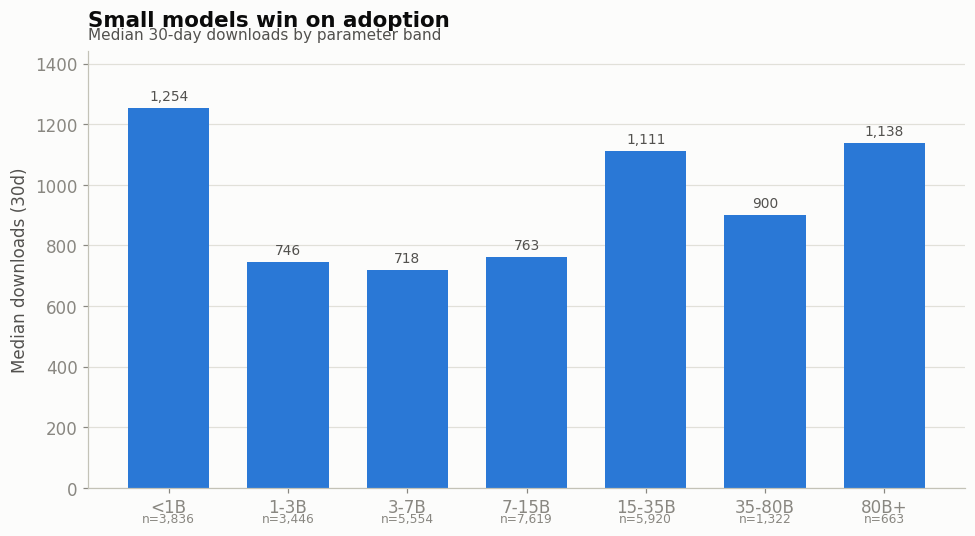

In [9]:
d = models.dropna(subset=['param_count_b'])
d = d[(d.param_count_b > 0.001) & (d.param_count_b < 1000)]

bins   = [0, 1, 3, 7, 15, 35, 80, 1000]
labels = ['<1B','1-3B','3-7B','7-15B','15-35B','35-80B','80B+']
d = d.assign(band=pd.cut(d.param_count_b, bins=bins, labels=labels))

g = d.groupby('band', observed=True)['downloads_30d'].median()
n = d.groupby('band', observed=True).size()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(g.index.astype(str), g.values, color=BLUE, width=0.68)
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_ylabel('Median downloads (30d)')

for i, (v, cnt) in enumerate(zip(g.values, n.values)):
    ax.text(i, v + max(g.values)*0.02, f'{int(v):,}', ha='center',
            fontsize=9, color=SECOND)
    ax.text(i, -max(g.values)*0.09, f'n={cnt:,}', ha='center',
            fontsize=8, color=MUTED)

ax.set_ylim(0, max(g.values) * 1.15)
finish(ax, 'Small models win on adoption',
       'Median 30-day downloads by parameter band')
plt.tight_layout(); plt.show()

## 3. Dating the local-inference wave

GGUF is the format used to run models locally on consumer hardware. Its share of new
repos over time dates the shift from *cloud-only* to *runs-on-your-laptop*.

Backfilled rows are excluded — this is exactly the analysis caveat #1 would ruin.

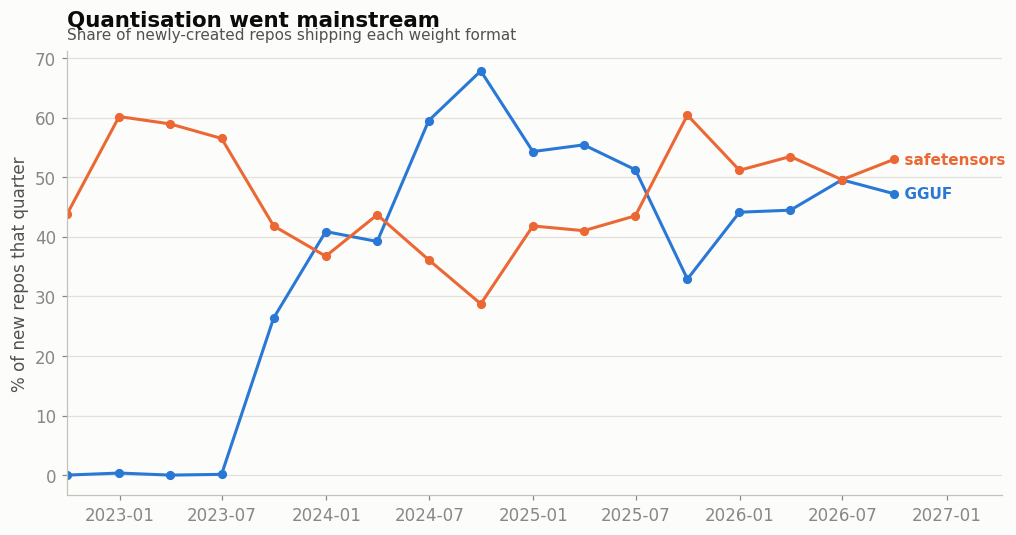

In [10]:
# Drop the March-2022 backfill sentinel before doing anything time-based.
SENTINEL = pd.Timestamp('2022-03-02')
ts = models[models.created_at.dt.normalize() != SENTINEL].dropna(subset=['created_at'])
ts = ts[ts.created_at >= '2022-06-01']

q = (ts.set_index('created_at')
       .groupby(pd.Grouper(freq='QE'))
       .agg(gguf=('has_gguf', 'mean'), safet=('has_safetensors', 'mean'), n=('model_id','size')))
q = q[q.n >= 100]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(q.index, q.gguf*100, color=BLUE, linewidth=2, marker='o', markersize=5)
ax.plot(q.index, q.safet*100, color=ORANGE, linewidth=2, marker='o', markersize=5)
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_ylabel('% of new repos that quarter')

# Direct labels instead of a legend box -- two series, both named on the plot.
ax.text(q.index[-1], q.gguf.iloc[-1]*100, '  GGUF', color=BLUE,
        fontweight='bold', va='center', fontsize=10)
ax.text(q.index[-1], q.safet.iloc[-1]*100, '  safetensors', color=ORANGE,
        fontweight='bold', va='center', fontsize=10)
ax.set_xlim(q.index[0], q.index[-1] + pd.Timedelta(days=190))

finish(ax, 'Quantisation went mainstream',
       'Share of newly-created repos shipping each weight format')
plt.tight_layout(); plt.show()

## 4. Popular but abandoned

A model with heavy downloads and no push in over a year is a real supply-chain risk —
people depend on code nobody maintains. `days_since_update` finds them.

In [11]:
stale = models[(models.days_since_update > 365) & (models.downloads_30d > 100_000)]
stale = stale.sort_values('downloads_30d', ascending=False)

print(f'{len(stale):,} models: >100K downloads/30d AND no update in over a year\n')
print(stale[['model_id','downloads_30d','likes','days_since_update','license']]
      .head(15).to_string(index=False))

1,309 models: >100K downloads/30d AND no update in over a year

                         model_id  downloads_30d  likes  days_since_update    license
    google-bert/bert-base-uncased      115858176   2733                907 apache-2.0
           BAAI/bge-small-en-v1.5       72653415    532                904        mit
google/electra-base-discriminator       54813706    153                897 apache-2.0
   lpiccinelli/unidepth-v2-vitl14       36732644     50                532        NaN
                      BAAI/bge-m3       34918885   3400                771        mit
                  Qwen/Qwen3-0.6B       29660008   1511                384 apache-2.0
               google-t5/t5-small       22831152    592               1141 apache-2.0
     openai/clip-vit-base-patch32       20825117   1000                897        NaN
          BAAI/bge-reranker-v2-m3       18569900   1134                781 apache-2.0
      FacebookAI/xlm-roberta-base       17781846    882                907  

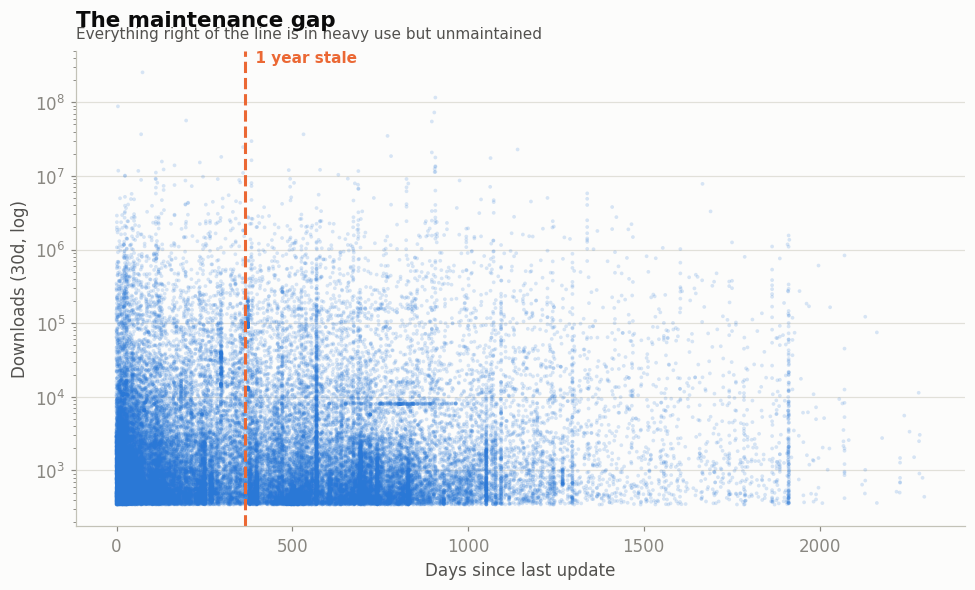

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
s = models[models.downloads_30d > 0]
ax.scatter(s.days_since_update, s.downloads_30d, s=6, alpha=0.18,
           color=BLUE, edgecolors='none')
ax.set_yscale('log')
ax.axvline(365, color=ORANGE, linewidth=2, linestyle='--')
ax.text(365, ax.get_ylim()[1], '  1 year stale', color=ORANGE,
        fontweight='bold', va='top', fontsize=10)
ax.set_xlabel('Days since last update'); ax.set_ylabel('Downloads (30d, log)')
ax.yaxis.grid(True); ax.xaxis.grid(False)
finish(ax, 'The maintenance gap',
       'Everything right of the line is in heavy use but unmaintained')
plt.tight_layout(); plt.show()

## 5. What each lab actually does

The author rollup exposes strategy. `pct_gguf` separates the quantisers from the
original-model labs; `n_tasks` separates the specialists from the generalists.

In [13]:
top = authors.nlargest(15, 'total_downloads_30d')[
    ['author','n_models','total_downloads_30d','total_likes',
     'pct_gguf','pct_finetunes','top_task']].copy()

fmt = top.assign(
    total_downloads_30d=top.total_downloads_30d.map('{:,.0f}'.format),
    total_likes=top.total_likes.map('{:,.0f}'.format),
    pct_gguf=top.pct_gguf.map('{:.0f}%'.format),
    pct_finetunes=top.pct_finetunes.map('{:.0f}%'.format),
)
print(fmt.to_string(index=False))

               author  n_models total_downloads_30d total_likes pct_gguf pct_finetunes                     top_task
sentence-transformers        98         371,387,436      11,225       0%            3%          sentence-similarity
                 Qwen       389         350,169,629     104,322      13%           58%              text-generation
                 BAAI        67         167,914,432      10,886       0%           10%           feature-extraction
               google       349         147,045,466      64,654       6%           18%           image-text-to-text
          google-bert        14         127,386,182       5,829       0%            0%                    fill-mask
        cross-encoder        34         105,142,780         887       0%           97%                 text-ranking
             facebook       488          76,624,436      29,981       0%            6%               text-to-speech
               openai        26          67,927,678      29,681       0%

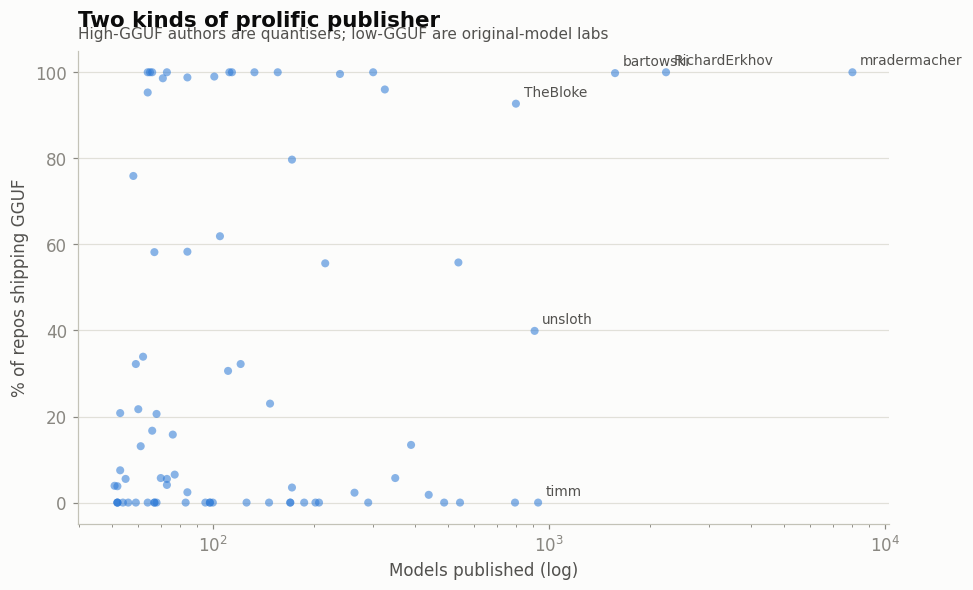

In [14]:
# Quantisers vs. originators among high-volume authors.
big = authors[authors.n_models >= 50].copy()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(big.n_models, big.pct_gguf, s=28, alpha=0.55,
           color=BLUE, edgecolors='none')
ax.set_xscale('log')
ax.set_xlabel('Models published (log)'); ax.set_ylabel('% of repos shipping GGUF')
ax.yaxis.grid(True); ax.xaxis.grid(False)

for _, r in big.nlargest(6, 'n_models').iterrows():
    ax.annotate(r.author, (r.n_models, r.pct_gguf), fontsize=9,
                color=SECOND, xytext=(5, 5), textcoords='offset points')

finish(ax, 'Two kinds of prolific publisher',
       'High-GGUF authors are quantisers; low-GGUF are original-model labs')
plt.tight_layout(); plt.show()

## Where to take this next

- **Predict `downloads_30d`** from task, licence, size, format and age. Heavy-tailed
  target — log-transform it, and expect `pipeline_tag` to carry most of the signal.
- **Build the fine-tune graph** from `base_model` (28,574 edges) and find the most-forked
  foundation models. `networkx` handles this in a few lines.
- **NLP on `tags`** — cluster models by tag co-occurrence and see whether the emergent
  groups match the official `pipeline_tag` taxonomy.
- **Licence risk audit** — join `license_bucket` against `downloads_30d` to size how much
  real-world usage sits on non-commercial terms.

---
